/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training tuned model...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0064
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0011
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 9.0549e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 8.7080e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 8.2698e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 7.6877e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 7.5185e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 7.0606e-04
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 6.8931e-04
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 7.2764e-04
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 6.4187e-04
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 6.5386e-04
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 6.1334e-04
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 6.0318e-04

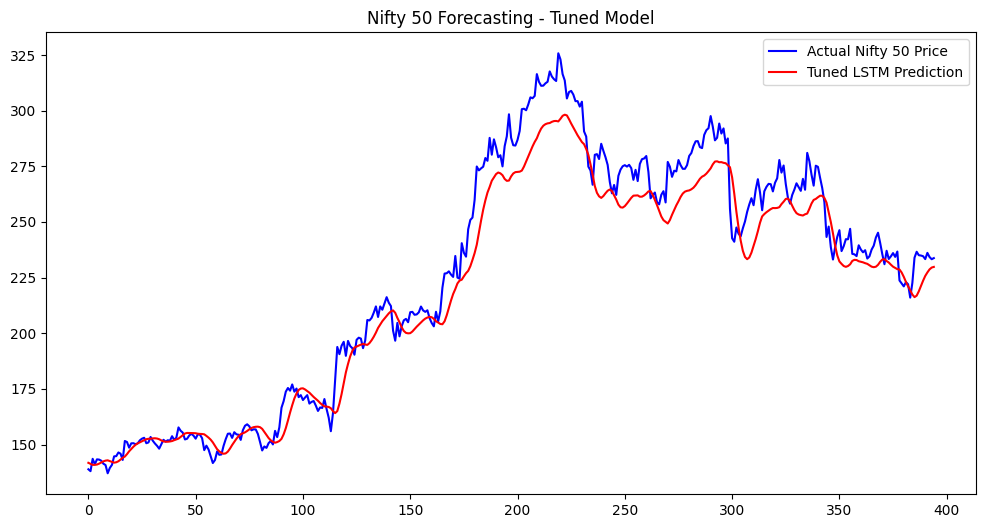

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


url = "https://raw.githubusercontent.com/mwitiderrick/stockprice/master/NSE-TATAGLOBAL.csv"
print("Downloading Nifty 50/Stock data...")
response = requests.get(url)
with open("nifty_data.csv", "wb") as f:
    f.write(response.content)

df = pd.read_csv("nifty_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
data = df[['Close']].values

# --- 2. DATA PREPARATION (Task 1 & 2) ---
#
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

# Setting a 60-day window for hyperparameter investigation
window_size = 60
X, y = create_sequences(scaled_data, window_size)

# Time Series Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# --- 3. TUNED MODEL ARCHITECTURE (Task 3 & 4) ---
#
model = Sequential([
    LSTM(100, activation='tanh', input_shape=(window_size, 1), return_sequences=True),
    Dropout(0.2), # Dropout added for tuning
    LSTM(50, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])

# Tuning learning rate to 0.0005 for better stability
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

# --- 4. TRAINING & EVALUATION (Task 5) ---
print("Training tuned model...")
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Predictions
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test)

# Results
print(f"\n--- Assignment 14 Results ---")
print(f"Test MAE: {mean_absolute_error(actual, predictions):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(actual, predictions)):.2f}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(actual, color='blue', label='Actual Nifty 50 Price')
plt.plot(predictions, color='red', label='Tuned LSTM Prediction')
plt.title('Nifty 50 Forecasting - Tuned Model')
plt.legend()
plt.show()